<a href="https://colab.research.google.com/github/rittase/actigraphy/blob/main/FWHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **To Start**

make sure runtime is connected - python

to get this running, connect the drive & install xlsxwriter

might need another install another package


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00


# **FWHM analysis**
I am pleased that this looks similar to the MPI data . . . just need to analyze

the below code generates a .csv containing the raw data

In [ ]:
import pandas as pd
import numpy as np
import os
from scipy.signal import find_peaks, peak_widths

# --- 1. SETTINGS ---
base_path = "/content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData"
cohorts = ['2.1', '2.2', '2.3', '2.4', '2.5']
DATA_LIMIT = 2881
# Smoothing window (e.g., 5 minutes) to help find peak shapes
SMOOTH_WINDOW = 5

fwhm_results = []

print("--- Extracting FWHM (Endurance) Data ---")

for cohort in cohorts:
    path = os.path.join(base_path, cohort)
    if not os.path.exists(path): continue

    files = [f for f in os.listdir(path) if f.endswith(".xlsx") and not f.startswith("~$")]

    for file in files:
        filepath = os.path.join(path, file)
        try:
            xls = pd.read_excel(filepath, sheet_name=None, header=None)
            for sheet, df_raw in xls.items():
                # Metadata
                sub_id = str(df_raw.iloc[0, 5]).strip()
                treat  = str(df_raw.iloc[0, 6]).strip()
                tpt    = str(df_raw.iloc[0, 8]).strip()

                # Raw VM data
                vm = pd.to_numeric(df_raw.iloc[1:DATA_LIMIT, 2], errors='coerce').fillna(0)

                # --- SMOOTHING & FWHM CALCULATION ---
                # Apply a rolling mean to smooth out the jitter
                smoothed_vm = vm.rolling(window=SMOOTH_WINDOW, center=True).mean().fillna(0)

                # Find peaks that exceed your threshold
                peaks, _ = find_peaks(smoothed_vm, height=5999)

                if len(peaks) > 0:
                    # peak_widths returns: (widths, width_heights, left_ips, right_ips)
                    # rel_height=0.5 gives us the Width at Half Maximum
                    widths = peak_widths(smoothed_vm, peaks, rel_height=0.5)[0]
                    avg_fwhm = np.mean(widths)
                else:
                    avg_fwhm = np.nan

                fwhm_results.append({
                    'Cohort': cohort,
                    'SubjectID': sub_id,
                    'Treatment': treat,
                    'TimePoint': tpt,
                    'Avg_FWHM_Minutes': avg_fwhm,
                    'Peak_Count': len(peaks)
                })
        except Exception as e:
            print(f"Error in {file}: {e}")

# Save results
fwhm_df = pd.DataFrame(fwhm_results)
fwhm_df['TimePoint'] = fwhm_df['TimePoint'].astype(str).str.replace('.0', '', regex=False)
fwhm_output = os.path.join(base_path, "FWHM_Analysis_Summary.csv")
fwhm_df.to_csv(fwhm_output, index=False)

print(f"✅ FWHM Summary saved to: {fwhm_output}")

--- Extracting FWHM (Endurance) Data ---
✅ FWHM Summary saved to: /content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData/FWHM_Analysis_Summary.csv


analysis below

# Analysis - graphs & stats

one file!  

In [ ]:
import pandas as pd
import os
import numpy as np
import statsmodels.api as sm
from pandas.api.types import CategoricalDtype
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. SETTINGS & LOADING ---
base_path = "/content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData"
input_csv = os.path.join(base_path, "FWHM_Analysis_Summary.csv")
df = pd.read_csv(input_csv)

# --- 2. CLEANING & ORDERING ---
df['TimePoint'] = df['TimePoint'].astype(str).str.replace('.0', '', regex=False).str.strip()
df['Treatment'] = df['Treatment'].astype(str).str.strip()

treat_order = ['Sham+Saline', 'Sham+Insulin', 'TBI+Saline', 'TBI+Insulin']
df['Treatment'] = df['Treatment'].astype(CategoricalDtype(categories=treat_order, ordered=True))

time_order = ['BL', '5', '12', '19', '26']
df['TimePoint'] = df['TimePoint'].astype(CategoricalDtype(categories=time_order, ordered=True))

# Now we analyze BOTH the duration (FWHM) and the Smoothed Frequency (Peak_Count)
variables = ['Avg_FWHM_Minutes', 'Peak_Count']

# --- 3. EXCEL VISUAL & STATS REPORT ---
output_report = os.path.join(base_path, "FWHM_and_PeakCount_Combined_Report.xlsx")
writer = pd.ExcelWriter(output_report, engine='xlsxwriter')
workbook = writer.book

for v in variables:
    sheet_name = v[:31]

    # Generate Tables
    mean_pivot = df.pivot_table(index='TimePoint', columns='Treatment', values=v, aggfunc='mean', observed=False)
    sd_pivot = df.pivot_table(index='TimePoint', columns='Treatment', values=v, aggfunc='std', observed=False)
    n_pivot = df.pivot_table(index='TimePoint', columns='Treatment', values=v, aggfunc='count', observed=False)

    # Write Tables
    mean_pivot.to_excel(writer, sheet_name=sheet_name, startrow=0, startcol=0)
    worksheet = writer.sheets[sheet_name]

    sd_row = len(mean_pivot) + 3
    worksheet.write(sd_row - 1, 0, "Standard Deviation (SD)")
    sd_pivot.to_excel(writer, sheet_name=sheet_name, startrow=sd_row, startcol=0)

    n_row = sd_row + len(sd_pivot) + 3
    worksheet.write(n_row - 1, 0, "Sample Size (N)")
    n_pivot.to_excel(writer, sheet_name=sheet_name, startrow=n_row, startcol=0)

    # --- Charting ---
    line_chart = workbook.add_chart({'type': 'line'})
    bar_chart = workbook.add_chart({'type': 'column'})
    colors = ['#808080', '#5B9BD5', '#ED7D31', '#C00000']

    for i, trt in enumerate(mean_pivot.columns):
        col_idx = i + 1
        series_opts = {
            'name':       [sheet_name, 0, col_idx],
            'categories': [sheet_name, 1, 0, len(mean_pivot), 0],
            'values':     [sheet_name, 1, col_idx, len(mean_pivot), col_idx],
            'line':       {'color': colors[i]},
            'fill':       {'color': colors[i]},
            'y_error_bars': {
                'type': 'custom',
                'plus_values':  [sheet_name, sd_row + 1, col_idx, sd_row + len(mean_pivot), col_idx],
                'minus_values': [sheet_name, sd_row + 1, col_idx, sd_row + len(mean_pivot), col_idx],
            },
        }
        line_chart.add_series(series_opts)
        bar_chart.add_series(series_opts)

    worksheet.insert_chart('G2', line_chart)
    worksheet.insert_chart('G22', bar_chart)

    # --- 4. STATS (ANOVA & TUKEY) ---
    temp_df = df.dropna(subset=[v]).copy()
    formula = f'{v} ~ C(Treatment) * C(TimePoint)'
    model = ols(formula, data=temp_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    temp_df['Combo'] = temp_df['Treatment'].astype(str) + "_" + temp_df['TimePoint'].astype(str)
    m_comp = pairwise_tukeyhsd(endog=temp_df[v], groups=temp_df['Combo'], alpha=0.05)
    posthoc_df = pd.DataFrame(data=m_comp._results_table.data[1:], columns=m_comp._results_table.data[0])

    # Write Stats below the tables (offset further down)
    stats_start_row = n_row + len(n_pivot) + 4
    worksheet.write(stats_start_row - 1, 0, "ANOVA Result")
    anova_table.to_excel(writer, sheet_name=sheet_name, startrow=stats_start_row)

    posthoc_start_row = stats_start_row + 8
    worksheet.write(posthoc_start_row - 1, 0, "Tukey Post-Hoc")
    posthoc_df.to_excel(writer, sheet_name=sheet_name, startrow=posthoc_start_row)

writer.close()
print(f"✅ Combined FWHM & Smoothed PeakCount Report created: {output_report}")

✅ Combined FWHM & Smoothed PeakCount Report created: /content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData/FWHM_and_PeakCount_Combined_Report.xlsx


# Example graphs?

prints example graphs in the output here in colab.  

probably can delete this, but leave here if I want to test something


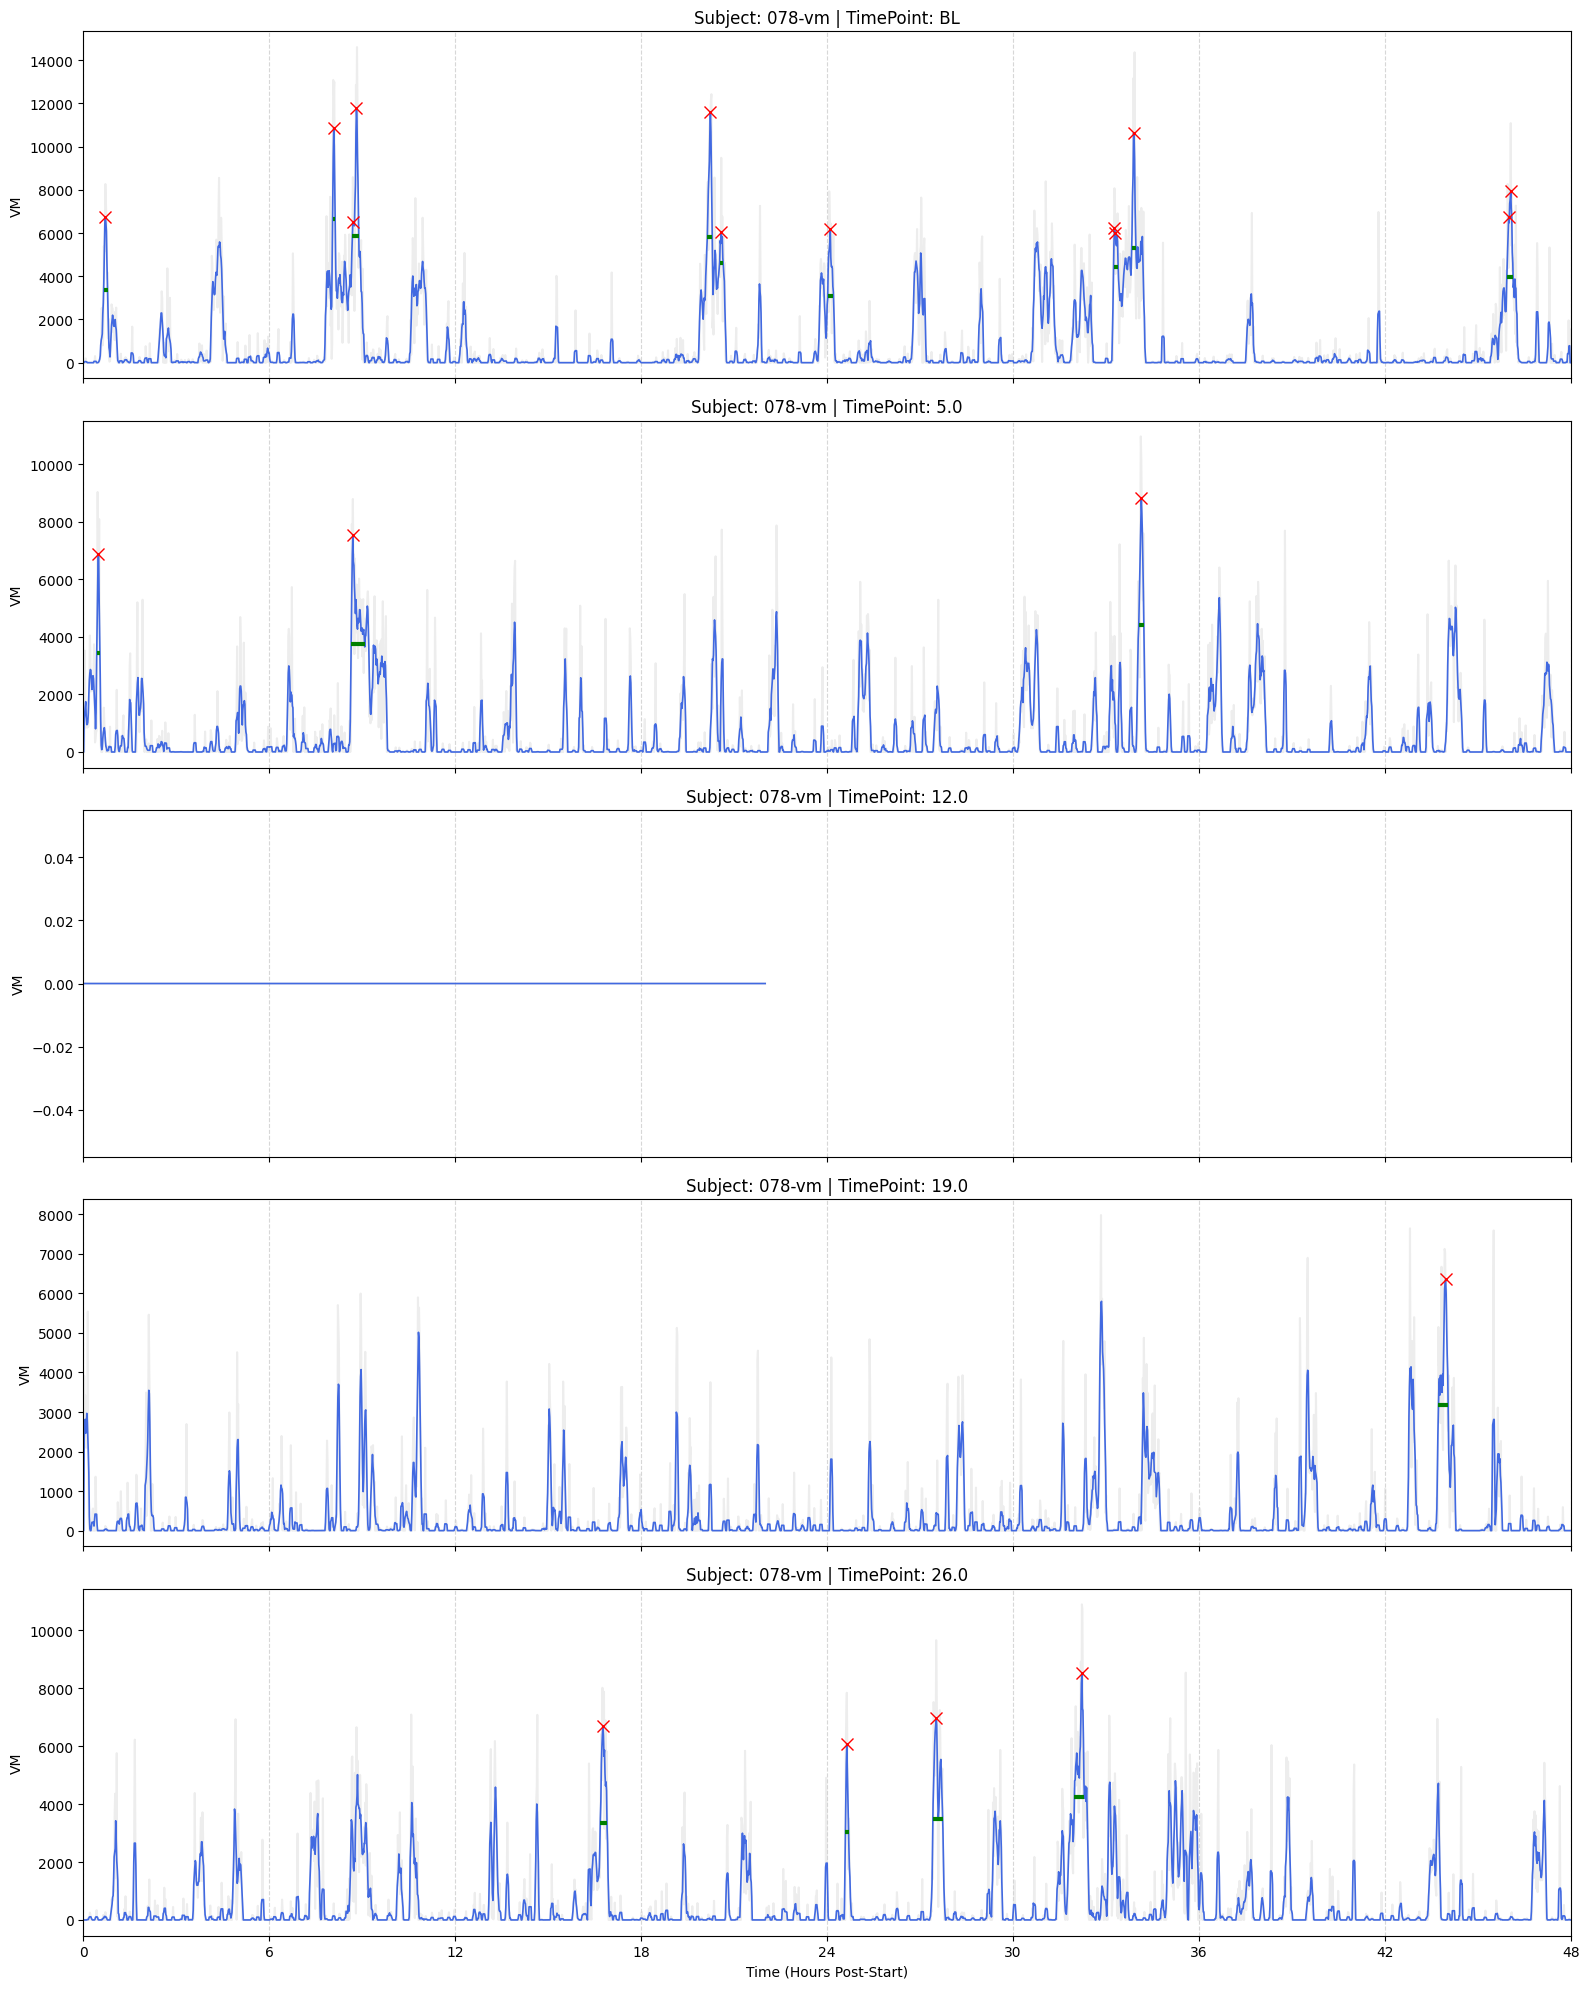

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# --- CONFIGURATION ---
base_path = "/content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData"
TARGET_COHORT = "2.1"
TARGET_SUBJECT = "078-vm" # Using the filename you provided

SMOOTH_WINDOW = 5
THRESHOLD = 5999
DATA_LIMIT = 2881

def plot_mouse_validation_v2(cohort, subject_id):
    path = os.path.join(base_path, cohort)
    # Ensure we handle the .xlsx extension correctly
    file_path = os.path.join(path, f"{subject_id}.xlsx")

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    xls = pd.read_excel(file_path, sheet_name=None, header=None)
    num_sheets = len(xls)

    fig, axes = plt.subplots(num_sheets, 1, figsize=(16, 4 * num_sheets), sharex=True)
    if num_sheets == 1: axes = [axes]

    for i, (sheet_name, df_raw) in enumerate(xls.items()):
        tpt = str(df_raw.iloc[0, 8]).strip()
        vm_raw = pd.to_numeric(df_raw.iloc[1:DATA_LIMIT, 2], errors='coerce').fillna(0).values

        # Calculate smoothed data
        smoothed_vm = pd.Series(vm_raw).rolling(window=SMOOTH_WINDOW, center=True).mean().fillna(0).values

        # Find peaks and FWHM
        peaks, _ = find_peaks(smoothed_vm, height=THRESHOLD)
        results_half = peak_widths(smoothed_vm, peaks, rel_height=0.5)

        ax = axes[i]

        # We divide the index by 60 to convert Minutes -> Hours
        hours_x = np.arange(len(vm_raw)) / 60

        ax.plot(hours_x, vm_raw, color='lightgray', alpha=0.4, label='Raw VM')
        ax.plot(hours_x, smoothed_vm, color='royalblue', linewidth=1.2, label='Smoothed')

        # Draw FWHM lines (convert peak indices to hours)
        # results_half[2] and [3] are the start/end indices of the width
        ax.hlines(results_half[1], results_half[2]/60, results_half[3]/60, color="green", linewidth=3)
        ax.plot(peaks/60, smoothed_vm[peaks], "x", color='red', markersize=8)

        # SET THE 6-HOUR TICKS
        ax.set_xticks(np.arange(0, 49, 6))
        ax.grid(axis='x', linestyle='--', alpha=0.5) # Vertical lines every 6 hours

        ax.set_title(f"Subject: {subject_id} | TimePoint: {tpt}", fontsize=12)
        ax.set_ylabel("VM")
        ax.set_xlim(0, 48) # Force the view to the full 48 hours

    axes[-1].set_xlabel("Time (Hours Post-Start)")
    plt.tight_layout()
    plt.show()

# Run it
plot_mouse_validation_v2(TARGET_COHORT, TARGET_SUBJECT)

code generates graphs and writes to an excel file

graphs in 2 forms - .png & excel files.  This is only for one animal
needs more work

do I want to run on more or even all the animals (I have 30 animals)


In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths

# --- CONFIGURATION ---
base_path = "/content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData"
TARGET_COHORT = "2.1"
TARGET_SUBJECT = "078-vm"

SMOOTH_WINDOW = 5
THRESHOLD = 5999
DATA_LIMIT = 2881

def generate_dual_report(cohort, subject_id):
    path = os.path.join(base_path, cohort)
    file_path = os.path.join(path, f"{subject_id}.xlsx")

    if not os.path.exists(file_path):
        print(f"❌ File not found: {file_path}")
        return

    xls = pd.read_excel(file_path, sheet_name=None, header=None)

    # 1. GENERATE THE SCIENTIFIC .PNG (The "Proof")
    num_sheets = len(xls)
    fig, axes = plt.subplots(num_sheets, 1, figsize=(16, 4 * num_sheets), sharex=True)
    if num_sheets == 1: axes = [axes]

    for i, (sheet_name, df_raw) in enumerate(xls.items()):
        vm_raw = pd.to_numeric(df_raw.iloc[1:DATA_LIMIT, 2], errors='coerce').fillna(0).values
        smoothed_vm = pd.Series(vm_raw).rolling(window=SMOOTH_WINDOW, center=True).mean().fillna(0).values
        peaks, _ = find_peaks(smoothed_vm, height=THRESHOLD)
        res = peak_widths(smoothed_vm, peaks, rel_height=0.5)

        ax = axes[i]
        ax.plot(vm_raw, color='lightgray', alpha=0.3)
        ax.plot(smoothed_vm, color='royalblue', linewidth=1)
        ax.hlines(res[1], res[2], res[3], color="green", linewidth=4)
        ax.set_title(f"Sheet: {sheet_name}")

    plt.tight_layout()
    img_path = os.path.join(base_path, "temp_validation.png")
    plt.savefig(img_path, dpi=150)
    plt.close()

    # 2. CREATE EXCEL WITH DATA & NATIVE CHARTS
    excel_output = os.path.join(base_path, f"{subject_id}_Dual_Report.xlsx")
    writer = pd.ExcelWriter(excel_output, engine='xlsxwriter')
    workbook = writer.book

    # Create a "Visual Summary" sheet for the .png
    summary_ws = workbook.add_worksheet('Scientific_Proof')
    summary_ws.insert_image('A2', img_path, {'x_scale': 0.6, 'y_scale': 0.6})

    # Create sheets for each TimePoint with Native Charts
    for sheet_name, df_raw in xls.items():
        vm_raw = pd.to_numeric(df_raw.iloc[1:DATA_LIMIT, 2], errors='coerce').fillna(0).values
        smoothed = pd.Series(vm_raw).rolling(window=SMOOTH_WINDOW, center=True).mean().fillna(0).values

        # Prepare data for Excel
        export_df = pd.DataFrame({'Minute': np.arange(len(vm_raw)), 'Raw_VM': vm_raw, 'Smoothed_VM': smoothed})
        export_df.to_excel(writer, sheet_name=sheet_name, index=False)

        # Add Native Excel Chart
        curr_ws = writer.sheets[sheet_name]
        chart = workbook.add_chart({'type': 'line'})

        # Series 1: Raw (Gray)
        chart.add_series({
            'name': 'Raw VM',
            'categories': [sheet_name, 1, 0, len(vm_raw), 0],
            'values':     [sheet_name, 1, 1, len(vm_raw), 1],
            'line':       {'color': '#D3D3D3', 'width': 0.75},
        })
        # Series 2: Smoothed (Blue)
        chart.add_series({
            'name': 'Smoothed VM',
            'categories': [sheet_name, 1, 0, len(vm_raw), 0],
            'values':     [sheet_name, 1, 2, len(vm_raw), 2],
            'line':       {'color': '#4169E1', 'width': 1.5},
        })

        chart.set_title({'name': f'Native Interaction: {sheet_name}'})
        chart.set_size({'width': 800, 'height': 400})
        curr_ws.insert_chart('E2', chart)

    writer.close()
    if os.path.exists(img_path): os.remove(img_path)
    print(f"✅ Dual Report Generated: {excel_output}")

generate_dual_report(TARGET_COHORT, TARGET_SUBJECT)

✅ Dual Report Generated: /content/drive/Othercomputers/My Computer/Documents/Insulin/actigraphy/VectorMagnitudeData/078-vm_Dual_Report.xlsx
